In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("dados.csv", encoding='latin1') #encoding=latin1, porque há símbolos ou caracteres que não estão em utf-8

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# **Preparação dos dados**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True) #datas do tipo objeto transformadas em datetime64
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

# **Produtos mais lucrativos**

## **Lucro por produto**

- **Top lucrativos:** copiadoras e impressoras (ex.: Canon imageCLASS 2200 Advanced Copier) aparecem como os maiores responsáveis pelo lucro.
- **Deficitários:** mesas de conferência e algumas impressoras 3D geram prejuízo.

**Insight:** investir nos produtos campeões e revisar a estratégia dos deficitários




In [9]:
df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10) #10 produtos que mais geraram lucro

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
Ativa V4110MDD Micro-Cut Shredder,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
Ibico EPK-21 Electric Binding System,3345.2823


# **Lucro por categoria e subcategoria**

- Copiers, Phones e Accessories são as subcategorias mais lucrativas.
- Tables e Bookcases apresentam prejuízo significativo.

**Insight:** tecnologia e suprimentos de escritório sustentam o negócio, enquanto móveis precisam de revisão de preços ou estratégia.




In [10]:
df.groupby("Category")["Profit"].sum()
df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False) #visão das subcategorias que puxam o lucro para cima e das que puxam o lucro para baixo

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


# **Sazonalidade de vendas**

- O gráfico de linha por ano-mês mostra picos nos finais dos anos.
- Há meses de baixa que indicam sazonalidade negativa.

**Insight:** campanhas promocionais podem ser planejadas para os meses fracos e reforçadas nos meses de alta.


In [11]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

<Axes: xlabel='Year,Month'>

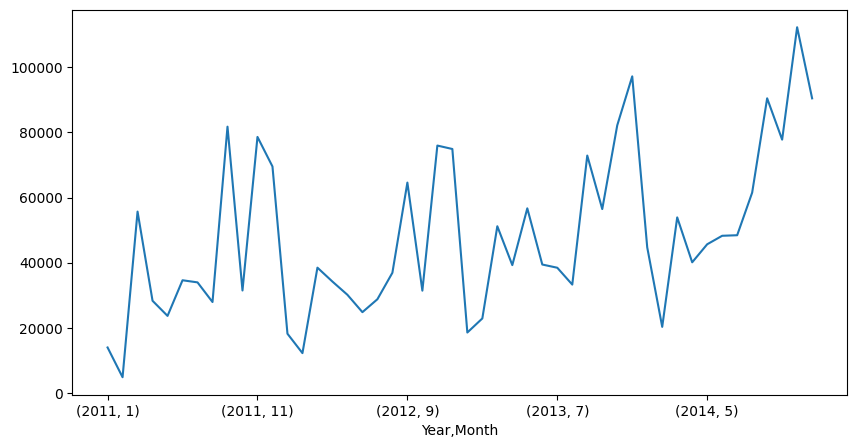

In [12]:
df.groupby(["Year","Month"])["Sales"].sum().plot(kind="line", figsize=(10,5)) #variação das vendas mês a mês ao longo dos anos

# **Comportamento dos clientes**




# **Top clientes por vendas**

- Cada ano tem seus “campeões” de vendas (ex.: Sean Miller em 2011, Tamara Chand em 2013).
- Não há um único cliente dominante em todo o período.

**Insight:** é essencial fidelizar clientes que aparecem como destaque em cada ano, para manter consistência.

In [13]:
df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10) #10 clientes que mais compraram em valor de vendas no período de 04/01/2011 a 31/12/2014

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [15]:
df["Year"] = df["Order Date"].dt.year

In [16]:
df.groupby(["Year","Customer Name"])["Sales"].sum().sort_values(ascending=False).head(10) #10 clientes que mais compraram em valor de vendas por ano

Year  Customer Name     
2011  Sean Miller           23661.228
2013  Tamara Chand          18344.052
2014  Raymond Buch          14203.278
      Tom Ashbrook          13723.498
2011  Sanjit Chand          12876.480
2013  Christopher Conant    11901.184
2011  Becky Martin          10539.896
2014  Hunter Lopez          10522.550
2013  Adrian Barton         10403.865
      Sanjit Engle           9879.220
Name: Sales, dtype: float64

# **Vendas por segmento**

- Segmentos como Consumer, Corporate e Home Office têm pesos diferentes nas vendas.
- Normalmente, Consumer tende a ser o maior, mas é importante comparar com o lucro para ver se o volume se traduz em rentabilidade.

**Insight:** direcionar estratégias de marketing conforme o segmento mais relevante.


In [17]:
df.groupby("Segment")["Sales"].sum()
df.groupby("Segment")["Profit"].sum()

,Profit
Segment,
Consumer,134119.2092
Corporate,91979.1340
Home Office,60298.6785


*Frequência de compras*

In [18]:
df["Customer ID"].value_counts().head(10)

,count
Customer ID,
WB-21850,37
MA-17560,34
JL-15835,34
PP-18955,34
CK-12205,32
JD-15895,32
EH-13765,32
SV-20365,32
ZC-21910,31


# **Análise gráfica**

# **1. Lucro por categoria**

/tmp/ipykernel_9439/2673239269.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_category.index, y=profit_by_category.values, palette="viridis")


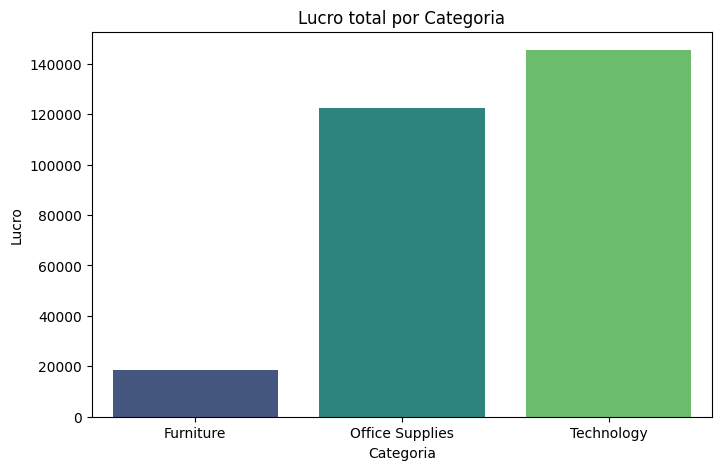

In [19]:
profit_by_category = df.groupby("Category")["Profit"].sum().sort_values()
plt.figure(figsize=(8,5))
sns.barplot(x=profit_by_category.index, y=profit_by_category.values, palette="viridis")
plt.title("Lucro total por Categoria")
plt.ylabel("Lucro")
plt.xlabel("Categoria")
plt.show()

# **2. Vendas mensais (Sazonalidade)**

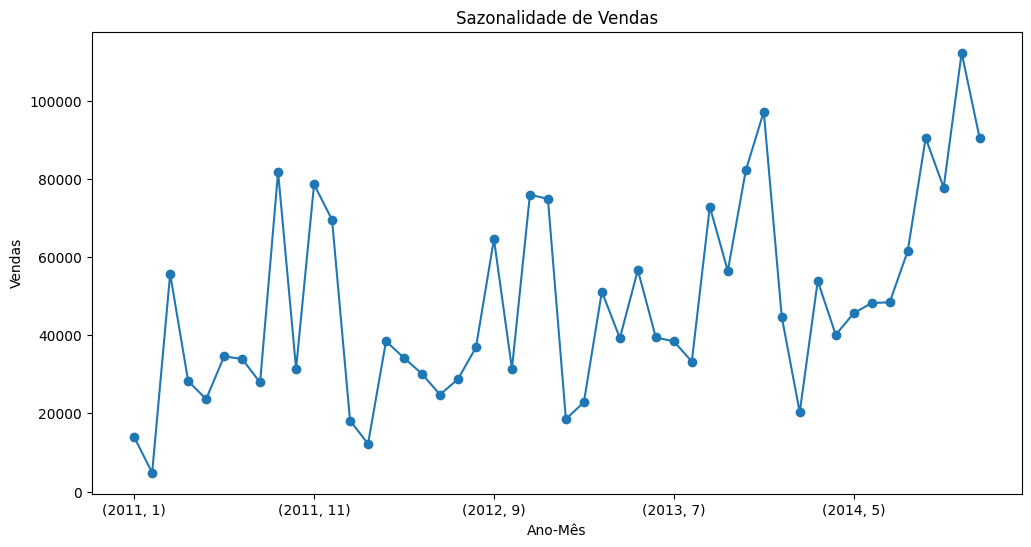

In [20]:
monthly_sales = df.groupby(["Year","Month"])["Sales"].sum()
monthly_sales.plot(kind="line", figsize=(12,6), marker="o")
plt.title("Sazonalidade de Vendas")
plt.ylabel("Vendas")
plt.xlabel("Ano-Mês")
plt.show()

# **3. Vendas por segmento**

/tmp/ipykernel_9439/1306323304.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_segment.index, y=sales_by_segment.values, palette="magma")


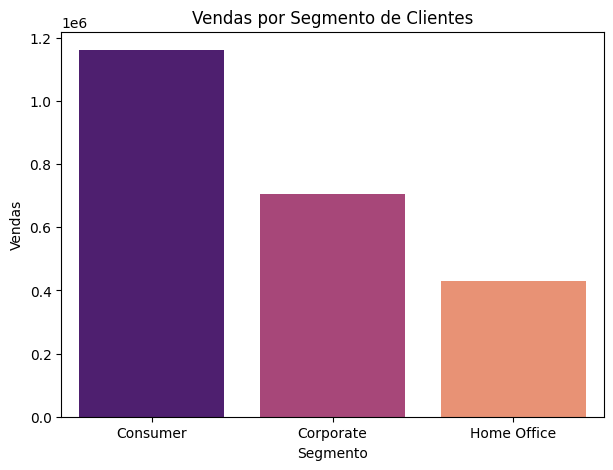

In [21]:
sales_by_segment = df.groupby("Segment")["Sales"].sum()
plt.figure(figsize=(7,5))
sns.barplot(x=sales_by_segment.index, y=sales_by_segment.values, palette="magma")
plt.title("Vendas por Segmento de Clientes")
plt.ylabel("Vendas")
plt.xlabel("Segmento")
plt.show()

In [22]:
df.to_csv("dados_atualizados.csv", index=False)

In [23]:
from google.colab import files
files.download("dados_atualizados.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>